# 12 — A surrogate as a co-simulation solver

`CoSimulationApplication` orchestrates partitioned multi-physics: each field is
solved by its own *solver wrapper*, and the coupled solver moves interface data
between them through data-transfer operators (MappingApplication mappers) and,
for strong coupling, convergence accelerators. This example deploys a trained
PhysicsNeMo surrogate as one of those solvers via
`cosim_surrogate_solver_wrapper` — the coupling loop cannot tell it apart from
a physics solver.

The scenario: a "structure" surrogate trained to map interface loads to
interface displacements (here the analytic map `d = 2 f + 1`, so every result
is exactly checkable), weakly coupled to a mock partner solver, then strongly
coupled through an Aitken-accelerated fixed-point loop.

In [1]:
import json
import tempfile
from pathlib import Path

import numpy
import torch
import matplotlib.pyplot as plt

import KratosMultiphysics as Kratos
import KratosMultiphysics.PhysicsNeMoApplication  # registers the application
from KratosMultiphysics.PhysicsNeMoApplication.training import training_utils
from KratosMultiphysics.CoSimulationApplication.co_simulation_analysis import CoSimulationAnalysis

workdir = Path(tempfile.mkdtemp(prefix="cosim_surrogate_"))
print("working in", workdir)

working in /tmp/cosim_surrogate_fzvnq3h9


## The interface mesh

The wrapper reads its interface into its own `Model` from a plain `.mdpa`
file — a nodes-only mesh suffices for `nearest_neighbor` data transfer. Here:
a 5×5 plate of interface nodes.

In [2]:
nodes = []
for j in range(5):
    for i in range(5):
        nodes.append((len(nodes) + 1, i / 4.0, j / 4.0, 0.0))

with open(workdir / "surrogate_interface.mdpa", "w") as f:
    f.write("Begin ModelPartData\nEnd ModelPartData\n\n")
    f.write("Begin Properties 0\nEnd Properties\n\n")
    f.write("Begin Nodes\n")
    for node_id, x, y, z in nodes:
        f.write(f"    {node_id}    {x}    {y}    {z}\n")
    f.write("End Nodes\n")
print(f"wrote {len(nodes)} interface nodes")

wrote 25 interface nodes


## Training the surrogate

The surrogate uses the wrapper's `"flat"` interface — the `InferenceProcess`
contract: input fields concatenated to `(n_nodes, 3)` (the interface `FORCE`),
output `(n_nodes, 3)` (the interface `DISPLACEMENT`). We train a small MLP on
synthetic samples of the analytic map `d = 2 f + 1` with the application's
`TrainModel`, and save it as TorchScript.

final training loss: 2.562e-05


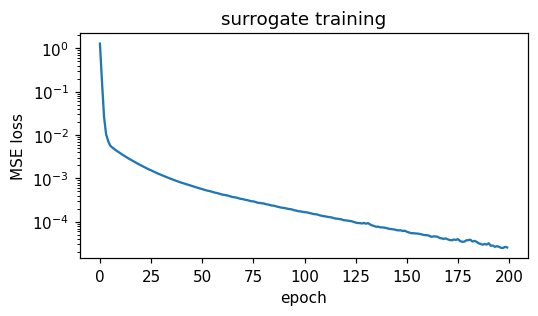

In [3]:
torch.manual_seed(0)
forces = torch.rand(4096, 3, dtype=torch.float64) * 2.0 - 1.0
displacements = 2.0 * forces + 1.0
dataset = torch.utils.data.TensorDataset(forces, displacements)

surrogate = torch.nn.Sequential(
    torch.nn.Linear(3, 32), torch.nn.Tanh(), torch.nn.Linear(32, 3)).double()
history = training_utils.TrainModel(surrogate, dataset, Kratos.Parameters("""{
    "epochs"        : 200,
    "batch_size"    : 256,
    "learning_rate" : 1e-2,
    "device"        : "auto",
    "seed"          : 0
}"""))
checkpoint = workdir / "structure_surrogate.pt"
training_utils.SaveTrainedModel(surrogate.cpu(), checkpoint)
print(f"final training loss: {history[-1]:.3e}")

plt.figure(figsize=(5, 3))
plt.semilogy(history)
plt.xlabel("epoch"); plt.ylabel("MSE loss"); plt.title("surrogate training")
plt.tight_layout(); plt.show()

## Weak (staggered) coupling

`coupled_solvers.gauss_seidel_weak`: the surrogate solves once per time step,
its predicted `DISPLACEMENT` is mapped (nearest-neighbor, identical clouds →
identity) into the partner's `FORCE`. The partner here is a second, untrained
instance of the same wrapper deploying an identity TorchScript model — a stand-in
for any real Kratos solver wrapper.

interface transfer rmse vs analytic map: 7.256e-03


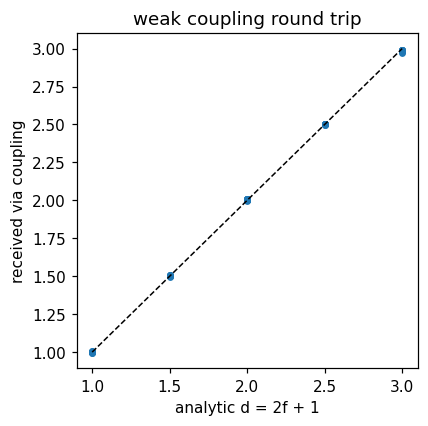

In [4]:
class Identity(torch.nn.Module):
    def forward(self, x):
        return x

torch.jit.script(Identity()).save(str(workdir / "identity.pt"))

def wrapper_block(checkpoint_file, time_step=0.0):
    return {
        "type": "KratosMultiphysics.PhysicsNeMoApplication.deployment.cosim_surrogate_solver_wrapper",
        "solver_wrapper_settings": {
            "mdpa_file": str(workdir / "surrogate_interface"),
            "time_step": time_step,
            "model_settings": {"checkpoint_file": str(checkpoint_file), "device": "auto"},
            "input_fields":  [{"variable_name": "FORCE",        "data_location": "node_historical"}],
            "output_fields": [{"variable_name": "DISPLACEMENT", "data_location": "node_historical"}]
        },
        "data": {
            "load": {"model_part_name": "Surrogate", "variable_name": "FORCE",        "dimension": 3},
            "disp": {"model_part_name": "Surrogate", "variable_name": "DISPLACEMENT", "dimension": 3}
        }
    }

weak_parameters = {
    "problem_data": {"start_time": 0.0, "end_time": 1.0, "echo_level": 0,
                     "print_colors": False, "parallel_type": "OpenMP"},
    "solver_settings": {
        "type": "coupled_solvers.gauss_seidel_weak",
        "echo_level": 0,
        "data_transfer_operators": {
            "mapper": {"type": "kratos_mapping",
                       "mapper_settings": {"mapper_type": "nearest_neighbor"}}},
        "coupling_sequence": [
            {"name": "structure", "input_data_list": [], "output_data_list": []},
            {"name": "partner", "input_data_list": [{
                "data": "load", "from_solver": "structure",
                "from_solver_data": "disp", "data_transfer_operator": "mapper"}],
             "output_data_list": []}],
        "solvers": {
            "structure": wrapper_block(workdir / "structure_surrogate.pt", time_step=1.0),
            "partner":   wrapper_block(workdir / "identity.pt")
        }
    }
}

analysis = CoSimulationAnalysis(Kratos.Parameters(json.dumps(weak_parameters)))
analysis.Initialize()
wrappers = analysis._GetSolver().solver_wrappers
for node in wrappers["structure"].model_part.Nodes:
    node.SetSolutionStepValue(Kratos.FORCE, [node.X, node.Y, 0.5])
analysis.RunSolutionLoop()
analysis.Finalize()

predicted = numpy.array([node.GetSolutionStepValue(Kratos.DISPLACEMENT)
                         for node in wrappers["partner"].model_part.Nodes])
expected = numpy.array([[2.0 * node.X + 1.0, 2.0 * node.Y + 1.0, 2.0]
                        for node in wrappers["partner"].model_part.Nodes])
rmse = numpy.sqrt(numpy.mean((predicted - expected) ** 2))
print(f"interface transfer rmse vs analytic map: {rmse:.3e}")

plt.figure(figsize=(4, 4))
plt.scatter(expected.ravel(), predicted.ravel(), s=12)
lo, hi = expected.min(), expected.max()
plt.plot([lo, hi], [lo, hi], "k--", lw=1)
plt.xlabel("analytic d = 2f + 1"); plt.ylabel("received via coupling")
plt.title("weak coupling round trip"); plt.tight_layout(); plt.show()

## Strong coupling with an Aitken accelerator

`coupled_solvers.gauss_seidel_strong` iterates the whole sequence inside each
time step until the interface residual converges. We couple a contraction
surrogate `d = 0.5 f + 1` against the identity partner: the fixed point of
`d = 0.5 d + 1` is `d = 2`, and the Aitken accelerator reaches it in a handful
of iterations. (A uniform scalar contraction produces collinear residuals —
exactly Aitken's regime; MVQN's secant Jacobian would be singular here.)

In [5]:
class Contraction(torch.nn.Module):
    def forward(self, x):
        return 0.5 * x + 1.0

torch.jit.script(Contraction()).save(str(workdir / "contraction.pt"))

strong_parameters = {
    "problem_data": {"start_time": 0.0, "end_time": 1.0, "echo_level": 0,
                     "print_colors": False, "parallel_type": "OpenMP"},
    "solver_settings": {
        "type": "coupled_solvers.gauss_seidel_strong",
        "echo_level": 0,
        "num_coupling_iterations": 15,
        "convergence_accelerators": [
            {"type": "aitken", "solver": "left", "data_name": "load"}],
        "convergence_criteria": [
            {"type": "relative_norm_previous_residual", "solver": "left",
             "data_name": "load", "abs_tolerance": 1e-10, "rel_tolerance": 1e-10}],
        "data_transfer_operators": {
            "mapper": {"type": "kratos_mapping",
                       "mapper_settings": {"mapper_type": "nearest_neighbor"}}},
        "coupling_sequence": [
            {"name": "left", "input_data_list": [{
                "data": "load", "from_solver": "right",
                "from_solver_data": "disp", "data_transfer_operator": "mapper"}],
             "output_data_list": []},
            {"name": "right", "input_data_list": [{
                "data": "load", "from_solver": "left",
                "from_solver_data": "disp", "data_transfer_operator": "mapper"}],
             "output_data_list": []}],
        "solvers": {
            "left":  wrapper_block(workdir / "contraction.pt", time_step=1.0),
            "right": wrapper_block(workdir / "identity.pt")
        }
    }
}

analysis = CoSimulationAnalysis(Kratos.Parameters(json.dumps(strong_parameters)))
analysis.Initialize()
wrappers = analysis._GetSolver().solver_wrappers
for node in wrappers["right"].model_part.Nodes:  # nonzero start: nonzero first residual
    node.SetSolutionStepValue(Kratos.DISPLACEMENT, [5.0, 5.0, 5.0])
analysis.RunSolutionLoop()
analysis.Finalize()

converged = numpy.array([node.GetSolutionStepValue(Kratos.DISPLACEMENT)
                         for node in wrappers["left"].model_part.Nodes])
print(f"fixed point reached: {converged.mean():.6f} (exact: 2.0), "
      f"max deviation {numpy.abs(converged - 2.0).max():.2e}")
assert numpy.abs(converged - 2.0).max() < 1e-3

fixed point reached: 2.000092 (exact: 2.0), max deviation 9.16e-05


## Takeaways

- `cosim_surrogate_solver_wrapper` is referenced by **module path** in the
  co-simulation `ProjectParameters` — no registration needed; the
  solver-wrapper factory falls back to `PYTHONPATH` imports.
- The surrogate exchanges data through the standard `CouplingInterfaceData` /
  data-transfer machinery, so it composes with any other Kratos solver wrapper
  (fluid, structure, thermal) and any mapper.
- `time_step > 0` makes the wrapper own the time; `0.0` lets the physics
  partner drive it.
- Strong coupling works because the surrogate's forward pass is deterministic
  under `no_grad` — the accelerators see a consistent fixed-point map.
- Any point-cloud interface (`transolver`, `geotransolver`, ...) can replace
  the `"flat"` contract for coordinate-aware surrogates.